# SAENAL Market — Sales Analysis & Forecast
**Author:** Park Dongjae
**Data Coverage:** July 2021 – July 2024
**Methods:** EDA · RFM-based SKU Segmentation · Category Portfolio Analysis · SARIMA vs. Prophet Forecasting · Vendor Concentration (HHI) · Correlation Analysis

---

This notebook walks through my end-to-end analysis of SAENAL Market's sales data.
The goal was to understand what's driving revenue, identify seasonal patterns,
evaluate the loyalty program, segment the product portfolio, quantify vendor
concentration risk, and forecast the next 12 months using the better of two
competing models.

## Table of Contents
1. [Libraries & Setup](#1)
2. [Data Loading](#2)
3. [Data Preprocessing](#3)
4. [Exploratory Data Analysis](#4)
5. [Customer & Product Behavior Analysis](#5)
6. [Revenue Forecasting (SARIMA vs. Prophet)](#6)
7. [Export for Tableau](#7)

---
## 1. Libraries & Setup <a id='1'></a>

In [1]:
import re
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

warnings.filterwarnings('ignore')

# Register a CJK-capable font so Category/Company labels (Korean) render as
# text instead of tofu boxes. DejaVu Sans (the v2 default) has no Hangul
# glyphs. Falls back quietly if the font isn't installed on this machine --
# use 'AppleGothic' on macOS or 'Malgun Gothic' on Windows instead.
for _path in ['/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc']:
    try:
        fm.fontManager.addfont(_path)
    except Exception:
        pass

plt.rcParams.update({
    'font.family'        : 'Noto Sans CJK JP',  # font file covers Hangul despite the JP-tagged name
    'axes.unicode_minus' : False,
    'figure.dpi'         : 120,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
})

print('Setup complete.')

Importing plotly failed. Interactive plots will not work.


Setup complete.


---
## 2. Data Loading <a id='2'></a>

The data came as separate Excel files per year — one for products and one for daily sales.
I wrote a helper function to load all four years at once and tag each row with its year,
so I don't have to repeat the same loading logic four times.

In [2]:
YEARS = [2021, 2022, 2023, 2024]

def load_yearly(prefix: str) -> pd.DataFrame:
    """Load all yearly Excel files for a given data type and stack them into one DataFrame."""
    frames = []
    for yr in YEARS:
        df = pd.read_excel(f'Saenal_market_{yr}_{prefix}.xlsx', engine='openpyxl')
        df['year'] = yr
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

products_raw  = load_yearly('product')
sales_raw     = load_yearly('sale')

# Category mapping and full product list are separate reference files
category_id   = pd.read_excel('Saenal_market_categoryID.xlsx',    engine='openpyxl')
products_list = pd.read_excel('Saenal_market_products_list.xlsx', engine='openpyxl')

print(f'products_raw : {products_raw.shape}')
print(f'sales_raw    : {sales_raw.shape}')
products_raw.head(3)

products_raw : (4297, 9)
sales_raw    : (1127, 10)


,상품명,평균 상품금액,주문건수,취소·반품 개수,취소·반품률,결제금액,환불금액,매출금액,year
0,[밥도둑푸드] 간편한 전라도 우거지 된장 4인분 250g,3500,2406,43,1.7871986699916873%,8421000,150500,8270500,2021
1,[자연향기] 하동 녹차 명란김 24봉(3x8봉),18000,2185,44,2.013729977116705%,39330000,792000,38538000,2021
2,[밥도둑푸드] 특허상품 노니 순살고등어 1팩 160g 내외,5000,1286,34,2.6438569206842923%,6430000,170000,6260000,2021


---
## 3. Data Preprocessing <a id='3'></a>

The raw data had several issues I needed to handle before any analysis:
inconsistent product naming, missing company info, deprecated categories,
and Korean column names that needed to be translated for readability.

### 3.1 Rename columns & clean Refund Rate

In [3]:
# Translate Korean column names to English for easier downstream analysis
PRODUCT_COLS = {
    '상품명'        : 'Product',
    'year'          : 'Year',
    '평균 상품금액' : 'Avg. Price',
    '주문건수'      : 'Num. Order',
    '취소·반품 개수': 'Num. Refund',
    '취소·반품률'   : 'Refund Rate',
    '결제금액'      : 'Purchase $',
    '환불금액'      : 'Refund $',
    '매출금액'      : 'Revenues',
}

products = (
    products_raw
    .rename(columns=PRODUCT_COLS)
    [list(PRODUCT_COLS.values())]
    .assign(**{
        # Refund Rate came in as a string like '12.5%' — strip the % and convert to float
        'Refund Rate': lambda df:
            pd.to_numeric(
                df['Refund Rate'].astype(str).str.replace('%', '', regex=False),
                errors='coerce'
            )
    })
    # A few rows had Refund Rate > 100% which are clearly data entry errors
    .query('`Refund Rate` <= 100')
    .reset_index(drop=True)
)

print(products.shape)
products.dtypes

(4295, 9)


Product         object
Year             int64
Avg. Price       int64
Num. Order       int64
Num. Refund      int64
Refund Rate    float64
Purchase $       int64
Refund $         int64
Revenues         int64
dtype: object

### 3.2 Remove deprecated categories

After checking with the team, CATE88, CATE40, and CATE0 are no longer active.
I removed them so the analysis only reflects the current product lineup.

In [4]:
category_id = (
    category_id
    .rename(columns={'Category': '카테고리', 'Product Code': '카테고리 ID'})
    .dropna()
)

products_list = products_list.rename(columns={'카테고리ID': '카테고리 ID'})

# These categories were confirmed as deprecated — removing them keeps the analysis clean
DEPRECATED = {'CATE88', 'CATE40', 'CATE0'}
selling_products = products_list[
    ~products_list['카테고리 ID'].isin(DEPRECATED)
].copy()

selling_products = selling_products[
    ['상품명', '자체 상품코드', '카테고리 ID', '판매가', '세금', '할인적용대상', '할인금액']
]

# Fill missing discount info with safe defaults
selling_products['할인금액']     = selling_products['할인금액'].fillna(0)
selling_products['할인적용대상'] = selling_products['할인적용대상'].fillna('할인불가')

# Attach the human-readable category name
selling_prod_cate = selling_products.merge(category_id, on='카테고리 ID', how='left')

print('Active categories:', selling_prod_cate['카테고리 ID'].nunique())
selling_prod_cate[['상품명', '카테고리', '할인적용대상']].head()

Active categories: 39


,상품명,카테고리,할인적용대상
0,(★★★08월14일오픈예정)[크리스탈 클라우드] 프리미엄 완전 자동 전동 와인오프너,생활,회원
1,(★★★08월12일오픈예정)[경영푸드] 국내산 한우 1++ 진짜 언양불고기,식품,할인불가
2,(★★★08월12일오픈예정)[크리스탈 클라우드] 여행용 바름 네일&큐티클 리페어 에...,뷰티/다이어트,회원
3,(★★★08월09일오픈예정)[크리스탈 클라우드] 여행용 샤워기,욕실/세정/위생용품,회원
4,(★★★08월09일오픈예정)[고양옥] 원기회복! 기력충전! 최고의 보양식 염소고기 홍탕,국/탕/찌개/면,회원


### 3.3 Extract company names from product names

Most product names followed a pattern like `[CompanyName] Product description`.
I used a regex to pull out the company name from the brackets,
which let me fill in most of the missing Company field automatically.

In [5]:
def extract_company(name: str):
    """Extract company name from product names formatted as '[CompanyName] Product ...'."""
    m = re.search(r'\[(.+?)\]', str(name))
    return m.group(1).strip() if m else np.nan

products['Company']          = products['Product'].apply(extract_company)
selling_prod_cate['Company'] = selling_prod_cate['상품명'].apply(extract_company)

# Merge category and discount info into the main products table
df = products.merge(
    selling_prod_cate[['상품명', '카테고리', '할인적용대상']].rename(columns={'상품명': 'Product'}),
    on='Product', how='left'
).rename(columns={'카테고리': 'Category', '할인적용대상': 'Discount Target'})

print(df.shape)
df.isnull().sum()

(4305, 12)


Product              0
Year                 0
Avg. Price           0
Num. Order           0
Num. Refund          0
Refund Rate          0
Purchase $           0
Refund $             0
Revenues             0
Company            147
Category           895
Discount Target    895
dtype: int64

### 3.4 Handle missing values

For a small number of products where the bracket pattern didn't work,
I manually corrected the ones I could identify.
For the rest, I imputed Category and Discount Target using the most common
value within each company — since products from the same vendor tend to share
the same category and discount structure.

In [6]:
# Manual corrections for products I could identify by name
df.loc[df['Product'].str.contains('셀핀다',         na=False), 'Company'] = '셀핀다'
df.loc[df['Product'].str.contains('하동 녹차 명란김', na=False), 'Company'] = '자연향기'

# The bracket-extraction regex above pulled the full promo-campaign text out of a
# milestone SKU name (e.g. "[아임굿 1st 원데이 이벤트 100만포 돌파 감사 이벤트]") as if it
# were its own vendor. Folding it back into the real vendor now, before it can distort
# the vendor concentration analysis in Section 4.5.
df.loc[df['Company'].astype(str).str.startswith('아임굿'), 'Company'] = '아임굿'

# '개인결제창' rows are internal payment links, not real products — remove them
df = df[~df['Product'].str.contains('개인결제창', na=False)].copy()

# For remaining nulls, fill using the most common value per company
for col in ['Category', 'Discount Target']:
    df[col] = df.groupby('Company')[col].transform(
        lambda s: s.fillna(s.mode().iloc[0]) if not s.mode().empty else s
    )

# Anything still null gets labeled 'Unknown' to keep it visible in the analysis
df[['Company', 'Category', 'Discount Target']] = (
    df[['Company', 'Category', 'Discount Target']].fillna('Unknown')
)

print('Final shape:', df.shape)
print('Remaining nulls:')
print(df.isnull().sum())

Final shape: (4296, 12)
Remaining nulls:
Product            0
Year               0
Avg. Price         0
Num. Order         0
Num. Refund        0
Refund Rate        0
Purchase $         0
Refund $           0
Revenues           0
Company            0
Category           0
Discount Target    0
dtype: int64


### 3.5 Clean Whitespace Artifacts in Categorical Labels

While building the new analyses below (Sections 4.5, 4.6, 5.3) I noticed that
`Category`, `Company`, and `Discount Target` all carry a trailing non-breaking
space (`\xa0`) inherited from the source Excel export. It didn't break the v2
analysis because every row for a given label carried the *same* hidden
character, so `groupby()` still worked — but it's a landmine for exact-match
filtering (`df[df.Category == '건강']` silently returns nothing) and it would
have fragmented the vendor-name matching in the concentration analysis below.
Stripping it here before it propagates downstream.

In [7]:
for col in ['Company', 'Category', 'Discount Target']:
    df[col] = (
        df[col].astype(str)
        .str.replace('\xa0', ' ', regex=False)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

print('Cleaned label samples:')
df[['Company', 'Category', 'Discount Target']].drop_duplicates().head(3)

Cleaned label samples:


,Company,Category,Discount Target
0,밥도둑푸드,국/탕/찌개/면,할인불가
1,자연향기,수산/건어물/김,회원
2,밥도둑푸드,수산/건어물/김,회원


### 3.6 Aggregate daily sales to monthly

The sales file had one row per day. I aggregated it to monthly
to make seasonality patterns easier to see and to feed into SARIMA later.

In [8]:
sales = (
    sales_raw
    .assign(date  = lambda d: pd.to_datetime(d['일자']))
    .assign(year  = lambda d: d['date'].dt.year,
            month = lambda d: d['date'].dt.month)
)

# Pivot table: rows = month, columns = year (used for the multi-year line chart)
monthly_pivot = (
    sales.groupby(['year', 'month'])['매출']
    .sum()
    .unstack(level='year')
)

# Time-indexed series needed for SARIMA
monthly_ts = (
    sales.resample('ME', on='date')['매출']
    .sum()
    .rename('total_revenue')
    .reset_index()
    .rename(columns={'date': 'date'})
)

yearly_ts = sales.groupby('year')['매출'].sum()

print('monthly_pivot shape:', monthly_pivot.shape)
monthly_ts.tail()

monthly_pivot shape: (12, 4)


,date,total_revenue
32,2024-03-31,329222103
33,2024-04-30,352307226
34,2024-05-31,392775862
35,2024-06-30,358965511
36,2024-07-31,223901086


---
## 4. Exploratory Data Analysis <a id='4'></a>

### 4.1 Revenue Trends Over Time

I started with the big picture — how does revenue look year over year,
and is there a consistent seasonal pattern month by month?

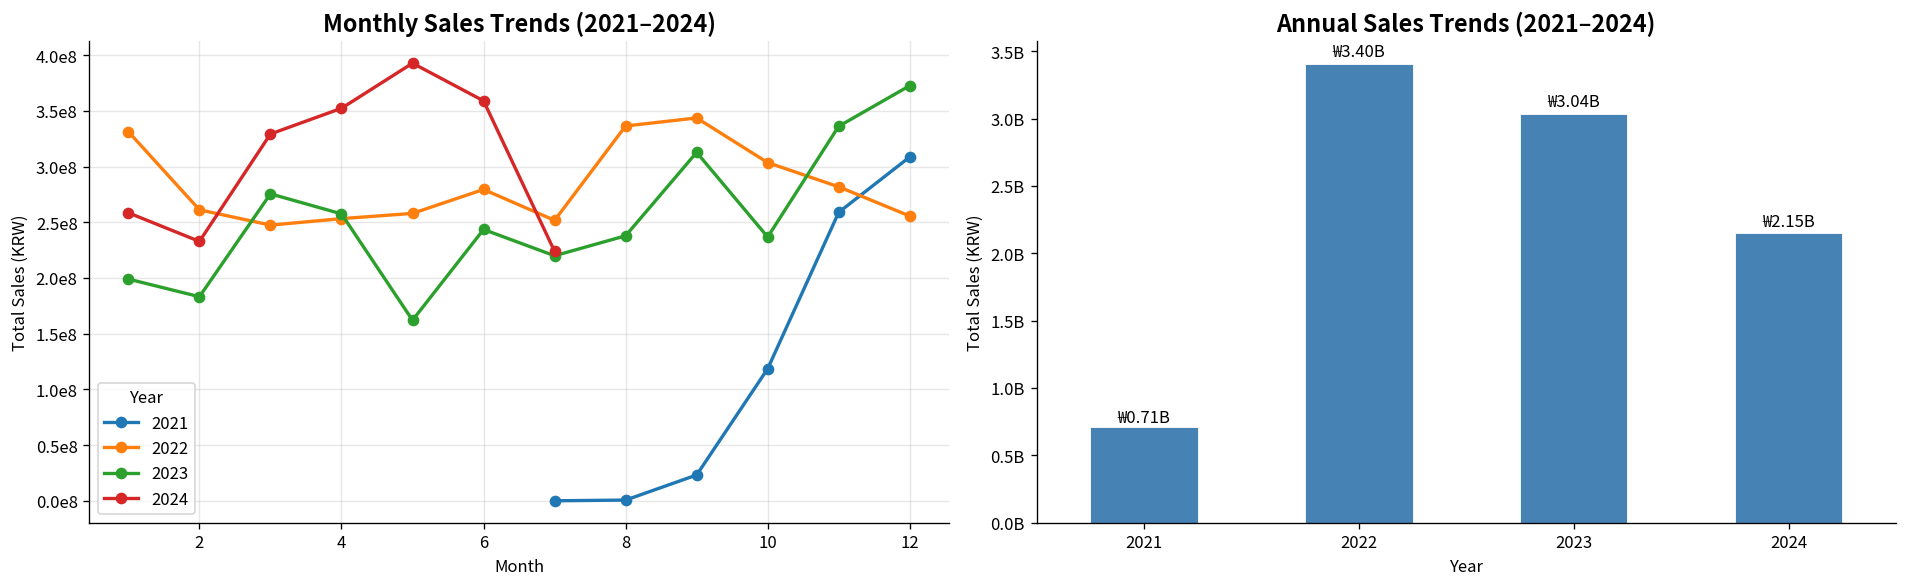

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly trends overlaid by year to spot recurring seasonal patterns
monthly_pivot.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title('Monthly Sales Trends (2021–2024)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales (KRW)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e8:.1f}e8'))
axes[0].grid(alpha=0.3)
axes[0].legend(title='Year')

# Annual totals to see overall growth trajectory
yearly_ts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_title('Annual Sales Trends (2021–2024)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Sales (KRW)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.01,
                 f'₩{bar.get_height()/1e9:.2f}B',
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('chart_revenue_trends.png', dpi=150, bbox_inches='tight')
plt.show()

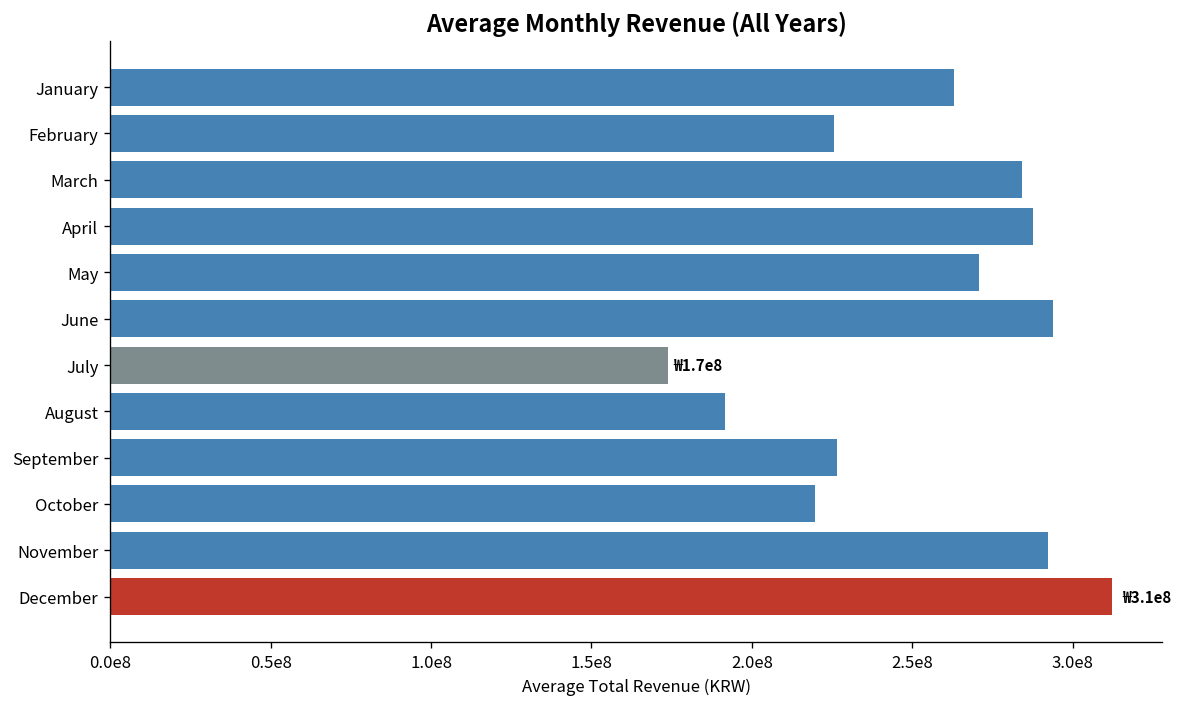

In [10]:
# Average revenue by calendar month across all years
# This makes the seasonal pattern much clearer than looking at individual years
MONTH_ORDER = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

avg_monthly = (
    monthly_ts
    .assign(month_name=lambda d: d['date'].dt.strftime('%B'))
    .groupby('month_name')['total_revenue'].mean()
    .reindex(MONTH_ORDER[::-1])  # reverse so December appears at the top
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

# Highlight the peak and trough months in different colors
colors = ['#c0392b' if r == avg_monthly['total_revenue'].max() else
          '#7f8c8d' if r == avg_monthly['total_revenue'].min() else
          'steelblue' for r in avg_monthly['total_revenue']]

bars = ax.barh(avg_monthly['month_name'], avg_monthly['total_revenue'], color=colors)
ax.set_title('Average Monthly Revenue (All Years)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Total Revenue (KRW)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e8:.1f}e8'))

# Label the peak and trough values directly on the chart
for bar, val in zip(bars, avg_monthly['total_revenue']):
    if val in (avg_monthly['total_revenue'].max(), avg_monthly['total_revenue'].min()):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
                f'₩{val/1e8:.1f}e8', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_avg_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Category & Product Analysis

Next I broke down revenue by product category to understand
which segments are actually driving the business.

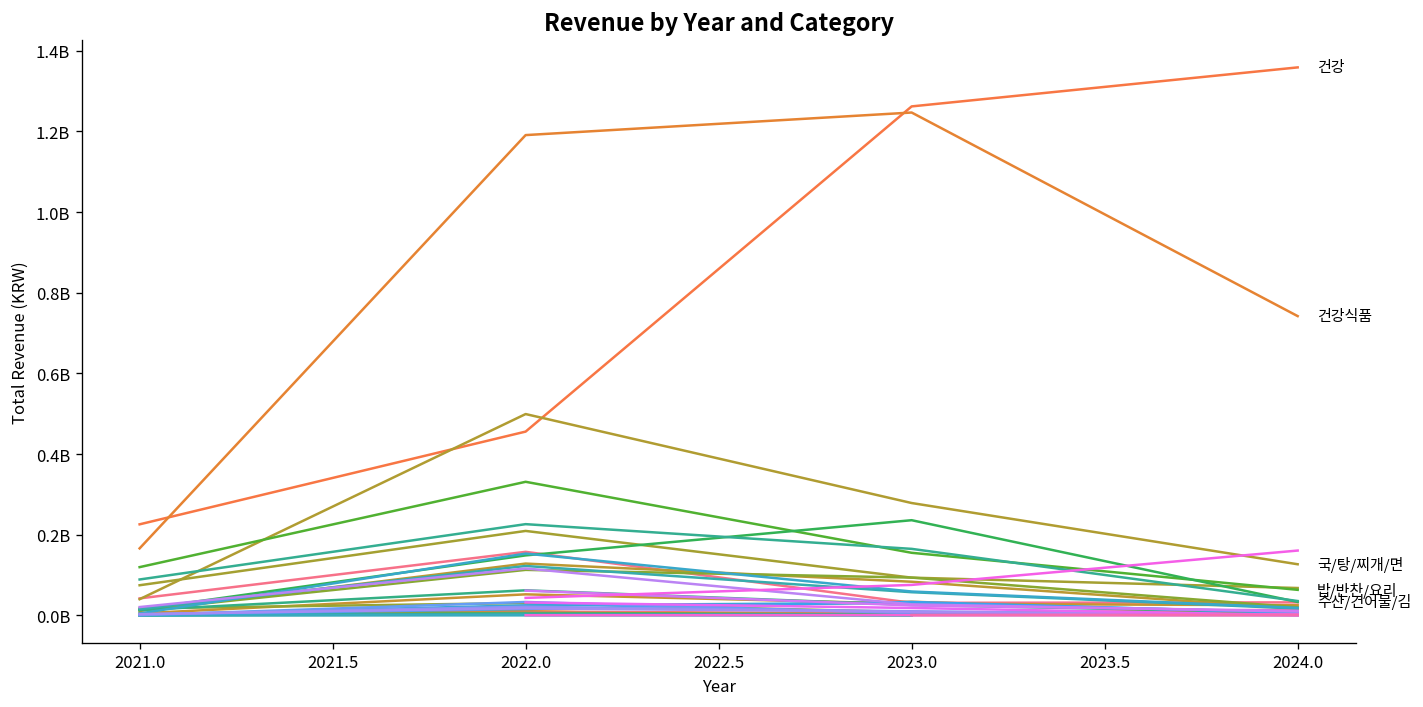

In [11]:
yearly_cat = (
    df.groupby(['Year', 'Category'])['Revenues']
    .sum()
    .reset_index()
)

# Identify the top 5 categories by total revenue for labeling
top5_cats = (
    yearly_cat.groupby('Category')['Revenues']
    .sum()
    .nlargest(5)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=yearly_cat, x='Year', y='Revenues',
             hue='Category', ax=ax, legend=False, linewidth=1.5)

# Only label the top 5 to keep the chart readable
last_year = yearly_cat['Year'].max()
for cat in top5_cats:
    row = yearly_cat[(yearly_cat['Category'] == cat) & (yearly_cat['Year'] == last_year)]
    if not row.empty:
        ax.text(last_year + 0.05, row['Revenues'].values[0],
                cat, fontsize=9, va='center')

ax.set_title('Revenue by Year and Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue (KRW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('chart_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

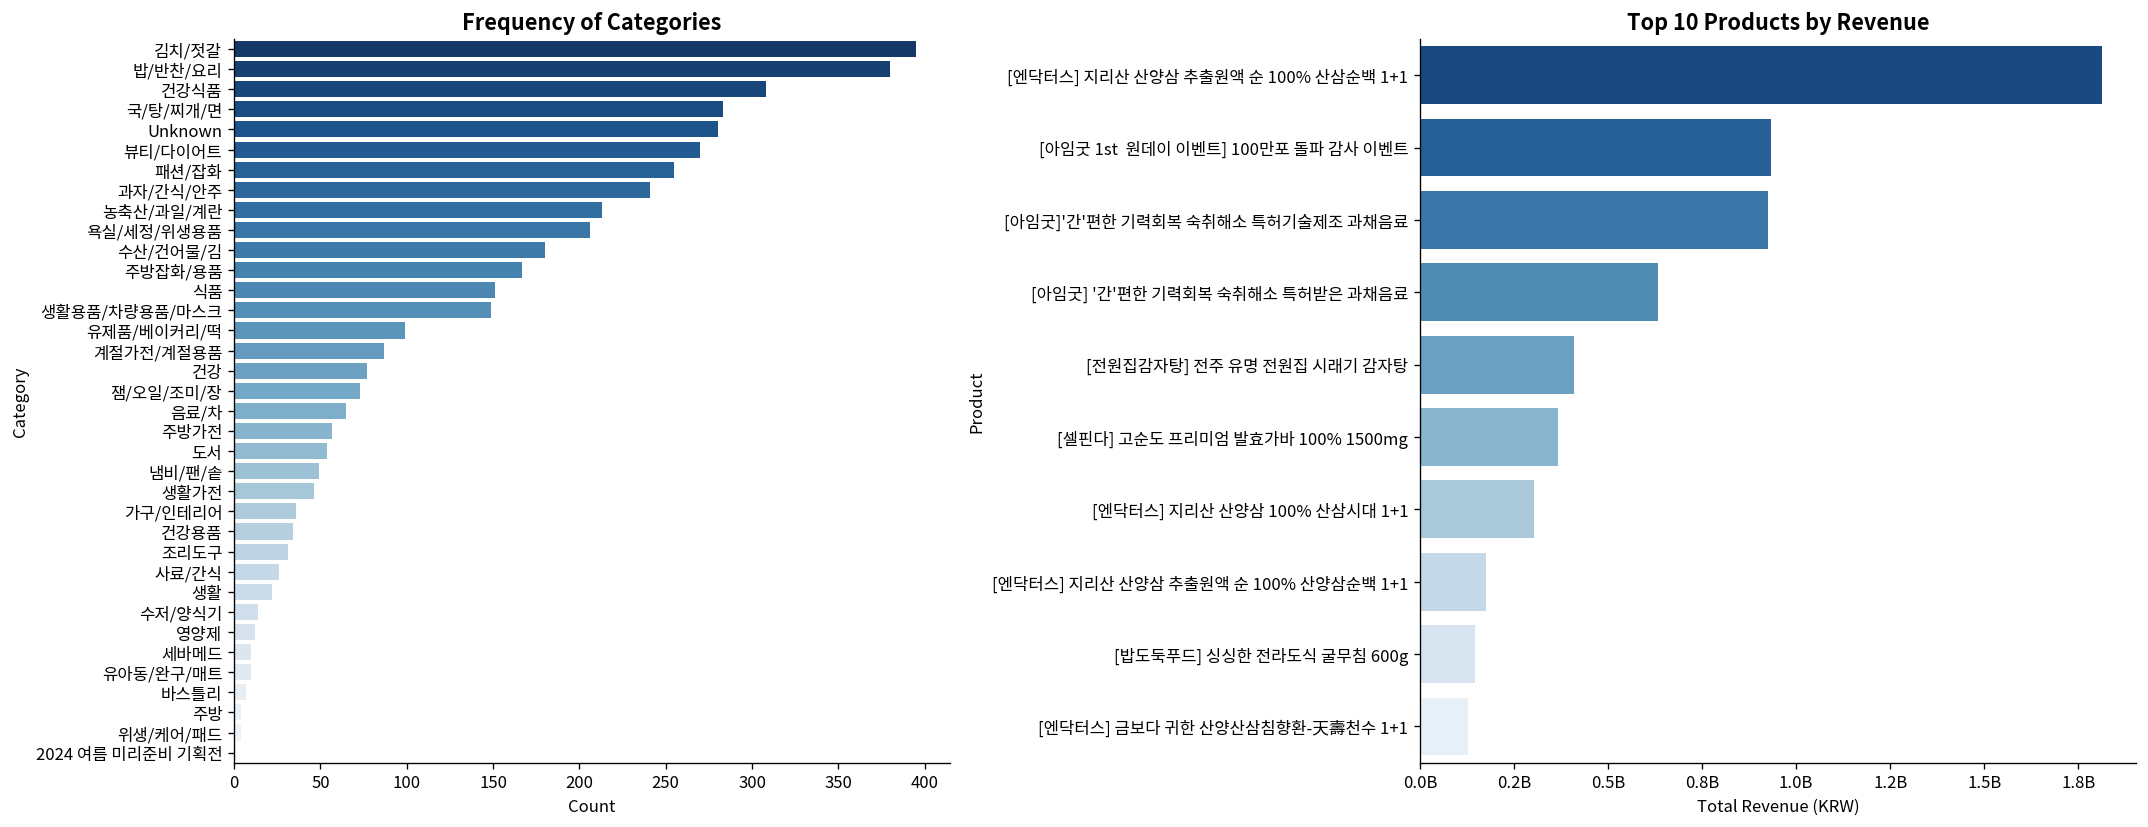

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# How many products exist in each category (breadth of offering)
cat_order = df['Category'].value_counts().index
sns.countplot(y='Category', data=df, order=cat_order,
              palette='Blues_r', ax=axes[0])
axes[0].set_title('Frequency of Categories', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

# Which individual products generated the most revenue overall
top10 = (
    df.groupby('Product')['Revenues'].sum()
    .nlargest(10)
    .reset_index()
)
sns.barplot(x='Revenues', y='Product', data=top10,
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].set_xlabel('Total Revenue (KRW)')

plt.tight_layout()
plt.savefig('chart_category_top10.png', dpi=150, bbox_inches='tight')
plt.show()

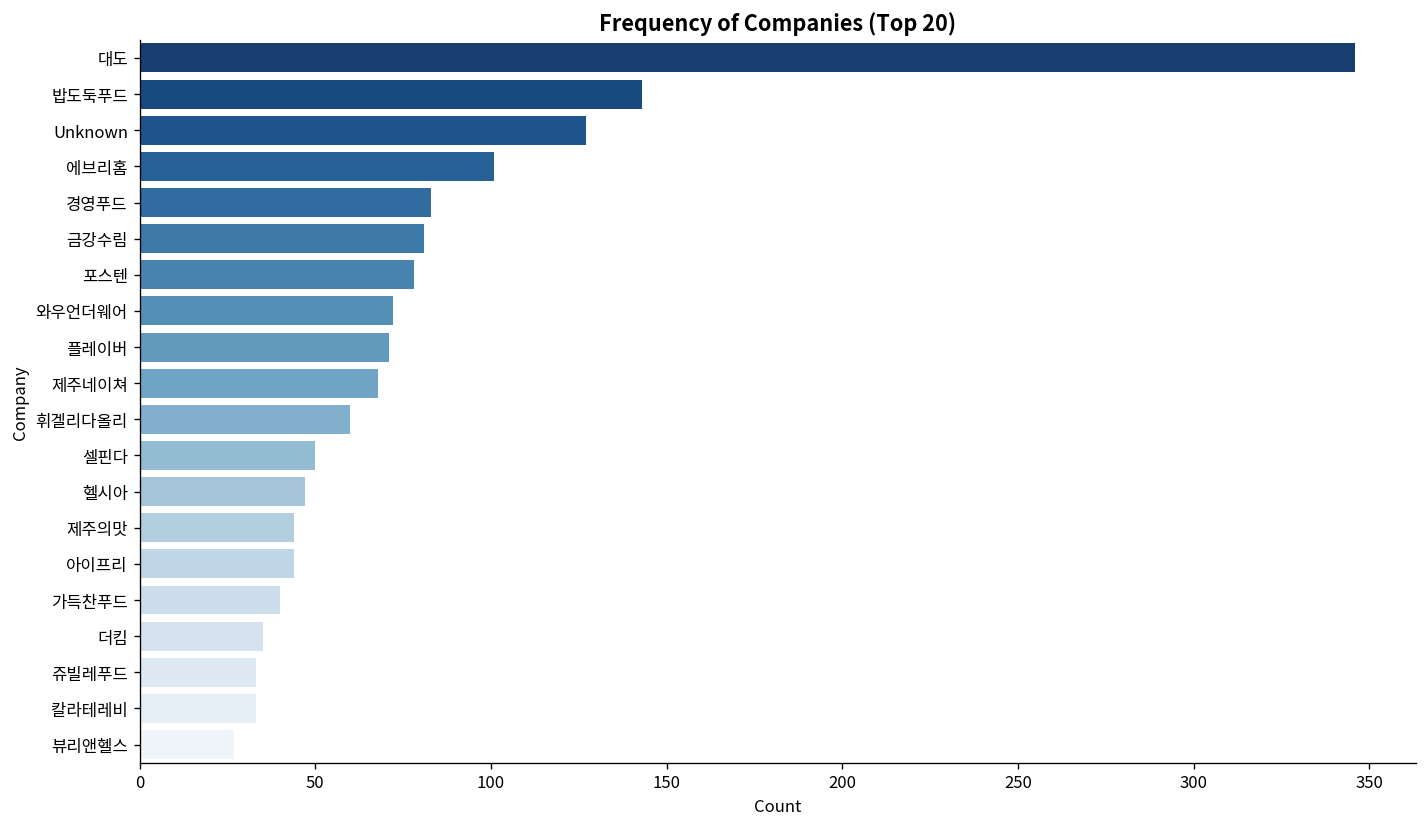

In [13]:
# Vendor concentration — I wanted to check if the platform was
# too dependent on a small number of suppliers
fig, ax = plt.subplots(figsize=(12, 7))
top20_companies = df['Company'].value_counts().head(20).index
sns.countplot(y='Company', data=df[df['Company'].isin(top20_companies)],
              order=top20_companies, palette='Blues_r', ax=ax)
ax.set_title('Frequency of Companies (Top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('chart_company_freq.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Discount Application Analysis

I segmented revenue by membership/discount type to understand
how much of the business relies on the loyalty program.

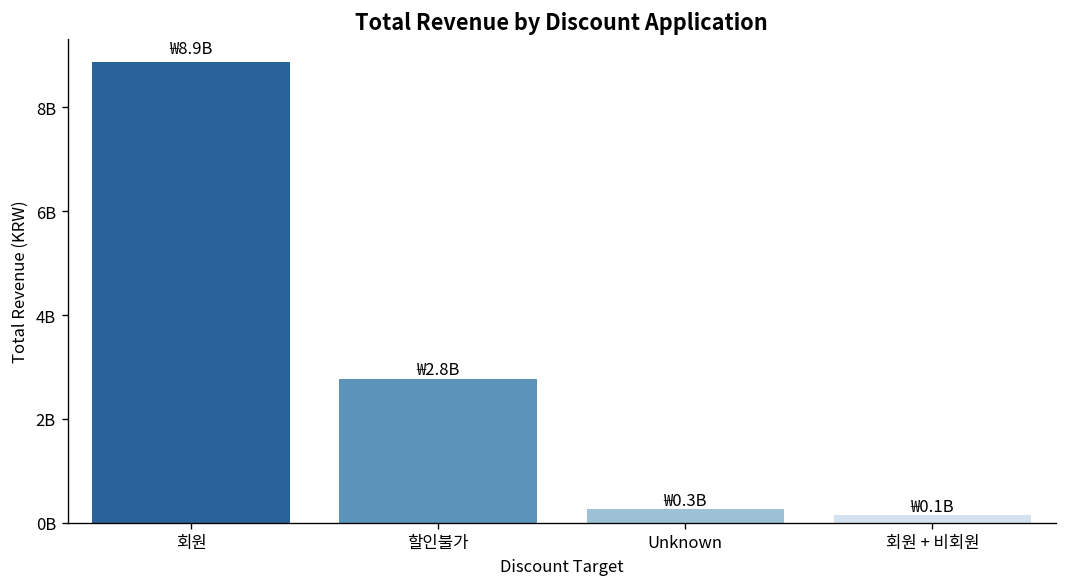

Member / Non-member revenue ratio: 3.2×


In [14]:
discount_rev = (
    df.groupby('Discount Target')['Revenues']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x='Discount Target', y='Revenues',
            data=discount_rev, palette='Blues_r', ax=ax)

# Add revenue labels on each bar so the gap between segments is immediately clear
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f'₩{bar.get_height()/1e9:.1f}B',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Total Revenue by Discount Application', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Revenue (KRW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
plt.tight_layout()
plt.savefig('chart_discount_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the member vs non-member revenue ratio
member_rev    = discount_rev.loc[discount_rev['Discount Target'] == '회원',    'Revenues'].values
nonmember_rev = discount_rev.loc[discount_rev['Discount Target'] == '할인불가', 'Revenues'].values
if member_rev.size and nonmember_rev.size:
    print(f'Member / Non-member revenue ratio: {member_rev[0] / nonmember_rev[0]:.1f}×')

### 4.4 Correlation Analysis

I ran a correlation matrix to check what actually drives revenue —
and what doesn't (price, refund rate, etc.).

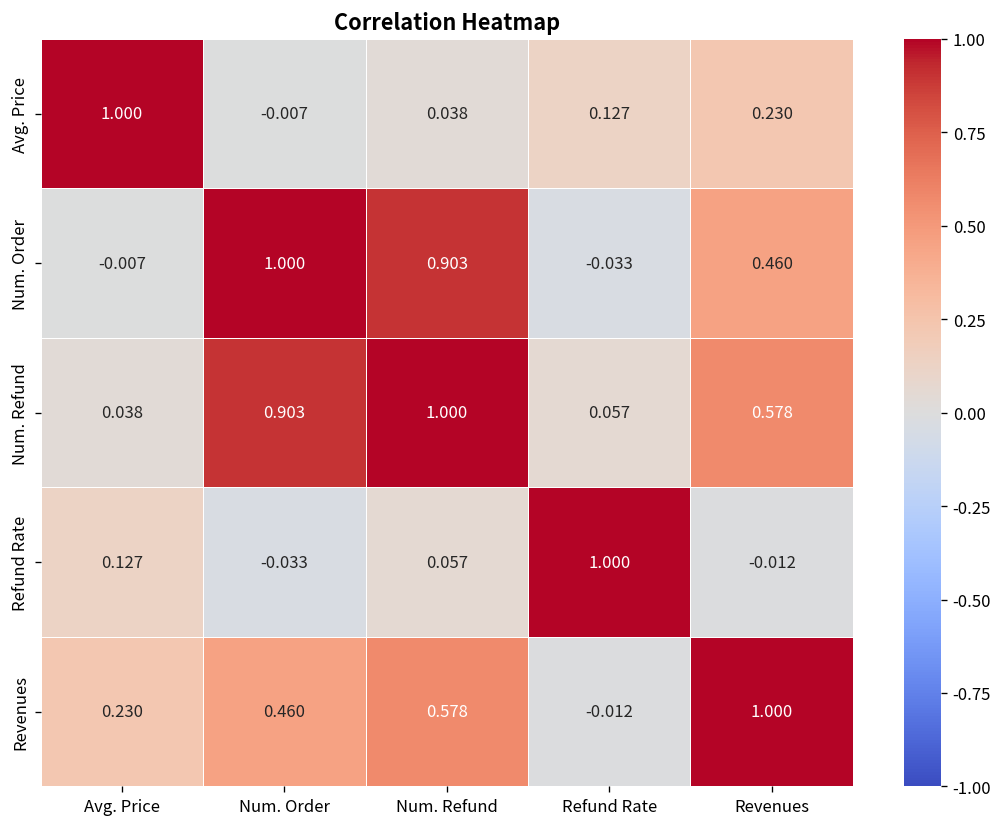


Correlations with Revenue (sorted):
Revenues       1.000000
Num. Refund    0.577617
Num. Order     0.459739
Avg. Price     0.229949
Refund Rate   -0.012239


In [15]:
CORR_COLS = ['Avg. Price', 'Num. Order', 'Num. Refund', 'Refund Rate', 'Revenues']
corr_matrix = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='coolwarm',
    vmin=-1, vmax=1,   # full range so negative correlations show correctly in blue
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelations with Revenue (sorted):')
print(corr_matrix['Revenues'].sort_values(ascending=False).to_string())

### 4.5 Vendor Concentration — Quantifying the Risk (HHI / CR4)

The listing-frequency chart above (*Frequency of Companies*) is what the v2
report used to flag vendor concentration risk — 대도 has by far the most rows
in the dataset. But "number of rows across four yearly snapshots" conflates a
vendor's *tenure* with its actual *economic weight*. A vendor listed every
year for four years accumulates more rows than one that launched a single
blockbuster SKU last year — even if the second vendor generates far more
revenue.

To actually quantify concentration risk I compute the Herfindahl–Hirschman
Index (HHI — sum of squared market shares, 0–10,000 scale) and the top-4
concentration ratio (CR4) across four different bases: listing frequency (the
old metric), unique SKU count, order volume, and revenue — the one that
actually matters for a "what happens if this vendor leaves" risk assessment.

In [16]:
def hhi_cr(share_pct):
    """share_pct: market shares in percent (0-100)."""
    hhi = (share_pct ** 2).sum()
    cr4 = share_pct.sort_values(ascending=False).head(4).sum()
    return hhi, cr4

vendor_base = df[df['Company'] != 'Unknown']

bases = {
    'Listing frequency (v2 metric)': vendor_base['Company'].value_counts(),
    'Unique SKU count'             : vendor_base.groupby('Company')['Product'].nunique(),
    'Order volume'                 : vendor_base.groupby('Company')['Num. Order'].sum(),
    'Revenue (economic weight)'    : vendor_base.groupby('Company')['Revenues'].sum(),
}

concentration_rows = []
for name, series in bases.items():
    share = series / series.sum() * 100
    hhi, cr4 = hhi_cr(share)
    concentration_rows.append({
        'Metric'     : name,
        'Top Vendor' : share.idxmax(),
        'Top Share %': round(share.max(), 1),
        'HHI'        : round(hhi),
        'CR4 %'      : round(cr4, 1),
    })

concentration_summary = pd.DataFrame(concentration_rows)
concentration_summary

,Metric,Top Vendor,Top Share %,HHI,CR4 %
0,Listing frequency (v2 metric),대도,8.3,128,16.1
1,Unique SKU count,경영푸드,3.2,56,10.8
2,Order volume,밥도둑푸드,15.1,368,30.3
3,Revenue (economic weight),아임굿,21.8,997,53.8


By revenue, the #1 vendor is '아임굿' at 21.8% of total platform revenue — exceeding the report's own 20%-per-vendor exposure cap recommendation.

'아임굿' share of category revenue (top 5 categories where present):
Category
건강식품                78.1
2024 여름 미리준비 기획전     0.0
유아동/완구/매트            0.0
수산/건어물/김             0.0
수저/양식기               0.0
dtype: float64


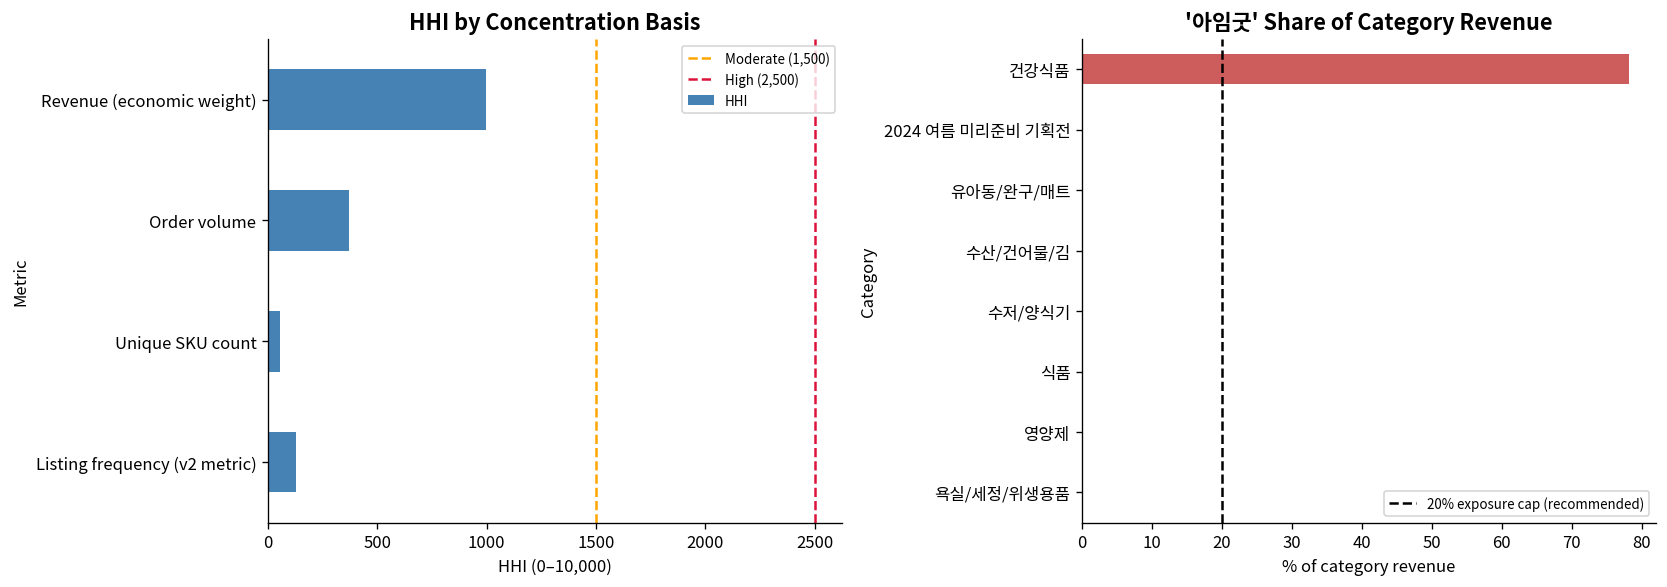

In [17]:
# HHI benchmark bands (U.S. DOJ/FTC merger guidelines, used here as a rule of thumb):
# <1,500 competitive | 1,500-2,500 moderately concentrated | >2,500 highly concentrated
rev_share  = bases['Revenue (economic weight)'] / bases['Revenue (economic weight)'].sum() * 100
top_vendor = rev_share.idxmax()
print(f"By revenue, the #1 vendor is '{top_vendor}' at {rev_share.max():.1f}% of total platform "
      f"revenue — exceeding the report's own 20%-per-vendor exposure cap recommendation.")

# Where is that vendor's revenue concentrated? (single-vendor exposure by category)
top_vendor_cat_share = (
    df.groupby('Category')
    .apply(lambda g: g.loc[g['Company'] == top_vendor, 'Revenues'].sum() / g['Revenues'].sum() * 100
           if g['Revenues'].sum() > 0 else 0)
    .sort_values(ascending=False)
)
print(f"\n'{top_vendor}' share of category revenue (top 5 categories where present):")
print(top_vendor_cat_share.head(5).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

concentration_summary.set_index('Metric')['HHI'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(1500, color='orange', linestyle='--', label='Moderate (1,500)')
axes[0].axvline(2500, color='crimson', linestyle='--', label='High (2,500)')
axes[0].set_title('HHI by Concentration Basis', fontsize=13, fontweight='bold')
axes[0].set_xlabel('HHI (0–10,000)')
axes[0].legend(fontsize=8)

top_vendor_cat_share.head(8).plot(kind='barh', ax=axes[1], color='indianred')
axes[1].invert_yaxis()
axes[1].axvline(20, color='black', linestyle='--', label='20% exposure cap (recommended)')
axes[1].set_title(f"'{top_vendor}' Share of Category Revenue", fontsize=13, fontweight='bold')
axes[1].set_xlabel('% of category revenue')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('chart_vendor_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the result:** by row-count, the platform looks reasonably
diversified (HHI in the "competitive" band). By revenue — the metric that
actually determines exposure if a vendor walks away — concentration jumps
into the "moderately concentrated" band, and the top vendor alone clears the
report's own recommended 20% single-vendor cap within its dominant category.
The original listing-frequency chart wasn't wrong, it was just answering a
different question than "how much revenue risk do we have."

### 4.6 Category Profitability Matrix (Growth–Share)

SAENAL Market doesn't capture COGS or margin at the product level, so a true
profitability matrix (margin × volume) isn't possible with this dataset. As a
profitability *proxy* I build a BCG-style growth-share matrix instead: YoY
revenue growth (2022→2023, the two full calendar years available) on one
axis, revenue share of the platform on the other. Bubble size = order volume,
color = quadrant. 'Unknown' is excluded since it's a data artifact, not a
real merchandising category.

In [18]:
cat_yearly = df.groupby(['Category', 'Year']).agg(
    Revenue=('Revenues', 'sum'),
    Orders=('Num. Order', 'sum'),
    Refund_Rate=('Refund Rate', 'mean'),
).reset_index()

rev_22 = cat_yearly.loc[cat_yearly.Year == 2022].set_index('Category')['Revenue']
cat_matrix = cat_yearly.loc[cat_yearly.Year == 2023].set_index('Category').copy()
cat_matrix['Revenue_2022'] = rev_22
cat_matrix = cat_matrix.dropna(subset=['Revenue_2022'])
cat_matrix = cat_matrix[cat_matrix['Revenue_2022'] > 0]
cat_matrix = cat_matrix[cat_matrix.index != 'Unknown']

cat_matrix['YoY_Growth_%']    = (cat_matrix['Revenue'] - cat_matrix['Revenue_2022']) / cat_matrix['Revenue_2022'] * 100
cat_matrix['Revenue_Share_%'] = cat_matrix['Revenue'] / cat_matrix['Revenue'].sum() * 100

share_thresh = cat_matrix['Revenue_Share_%'].mean()

def quadrant(row):
    high_share  = row['Revenue_Share_%'] >= share_thresh
    high_growth = row['YoY_Growth_%'] >= 0
    if high_share and high_growth:     return 'Star'
    if high_share and not high_growth: return 'Cash Cow'
    if not high_share and high_growth: return 'Question Mark'
    return 'Dog'

cat_matrix['Quadrant'] = cat_matrix.apply(quadrant, axis=1)
cat_matrix.sort_values('Revenue', ascending=False)[
    ['Revenue', 'YoY_Growth_%', 'Revenue_Share_%', 'Quadrant']
].head(12).round(1)

,Revenue,YoY_Growth_%,Revenue_Share_%,Quadrant
Category,,,,
건강,1262199400,177.0,31.0,Star
건강식품,1247025540,4.7,30.7,Star
국/탕/찌개/면,278408320,-44.2,6.8,Cash Cow
뷰티/다이어트,235803300,58.8,5.8,Star
수산/건어물/김,164714610,-27.1,4.0,Cash Cow
밥/반찬/요리,154963780,-53.2,3.8,Cash Cow
농축산/과일/계란,93467600,-17.0,2.3,Dog
김치/젓갈,93321200,-55.4,2.3,Dog
과자/간식/안주,83179060,-35.1,2.0,Dog


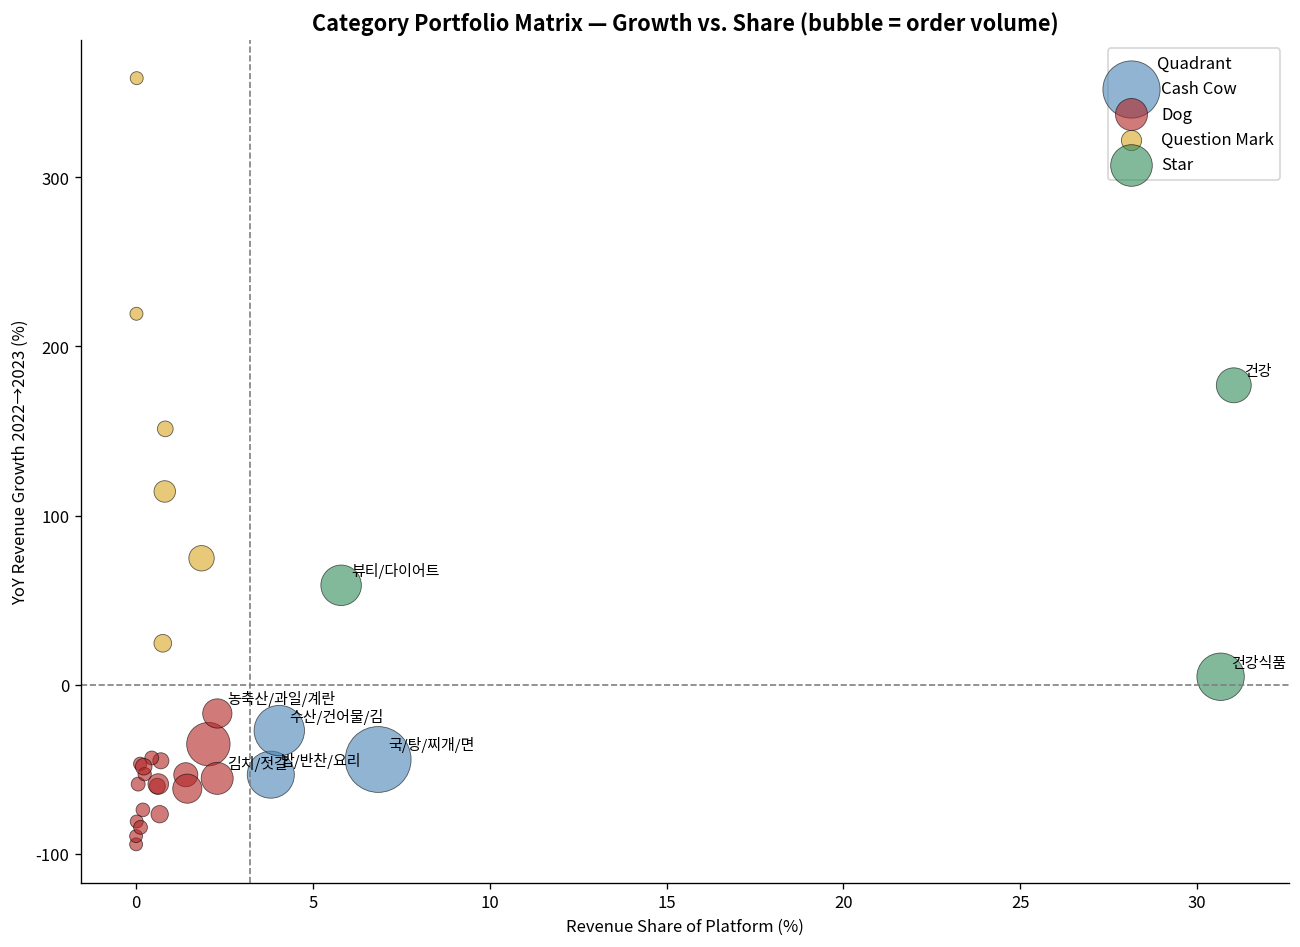

In [19]:
fig, ax = plt.subplots(figsize=(11, 8))
colors = {'Star': '#2E8B57', 'Cash Cow': '#4682B4', 'Question Mark': '#DAA520', 'Dog': '#B22222'}

for q, g in cat_matrix.groupby('Quadrant'):
    ax.scatter(g['Revenue_Share_%'], g['YoY_Growth_%'],
               s=g['Orders'] / cat_matrix['Orders'].max() * 1500 + 60,
               c=colors[q], alpha=0.6, edgecolors='black', linewidth=0.5, label=q)

# Label the top categories by revenue so the chart stays readable
for cat_name, row in cat_matrix.nlargest(8, 'Revenue').iterrows():
    ax.annotate(cat_name, (row['Revenue_Share_%'], row['YoY_Growth_%']),
                fontsize=9, xytext=(6, 6), textcoords='offset points')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(share_thresh, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Revenue Share of Platform (%)')
ax.set_ylabel('YoY Revenue Growth 2022→2023 (%)')
ax.set_title('Category Portfolio Matrix — Growth vs. Share (bubble = order volume)',
              fontsize=13, fontweight='bold')
ax.legend(title='Quadrant')
plt.tight_layout()
plt.savefig('chart_category_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**A data-quality fix upstream changed this result — worth flagging.** My
first pass at this matrix showed 건강식품 contracting 74% YoY, which
contradicted the v2 report's "sustained growth" claim. Tracing it down: the
Section 3.4 fix that folds the mislabeled `'아임굿 1st 원데이 이벤트...'`
vendor back into `'아임굿'` also fixes a knock-on problem — that single
promotional SKU (~₩930M in revenue) had a `Category` that never matched the
product master list, so it fell into `'Unknown'` instead of its real
category. With that corrected, `'Unknown'`'s 2023 revenue drops from ~₩965M
to ~₩31M, and 건강식품 turns out to be a second **Star**, essentially flat at
+4.7% YoY on a ₩1.19B → ₩1.25B base — matching the original report's
"sustained growth" characterization much more closely than my first read did.
Lesson for the writeup: one bracket-extraction bug was quietly inflating the
'Unknown' bucket by ~₩900M/year and misclassifying a real category's growth
trend — worth a QA pass on any '알 수 없음' revenue before trusting category
comparisons.

---
## 5. Customer Behavior Analysis <a id='5'></a>

Here I looked at how different customer segments and product types
behave across price, order volume, and refund patterns.

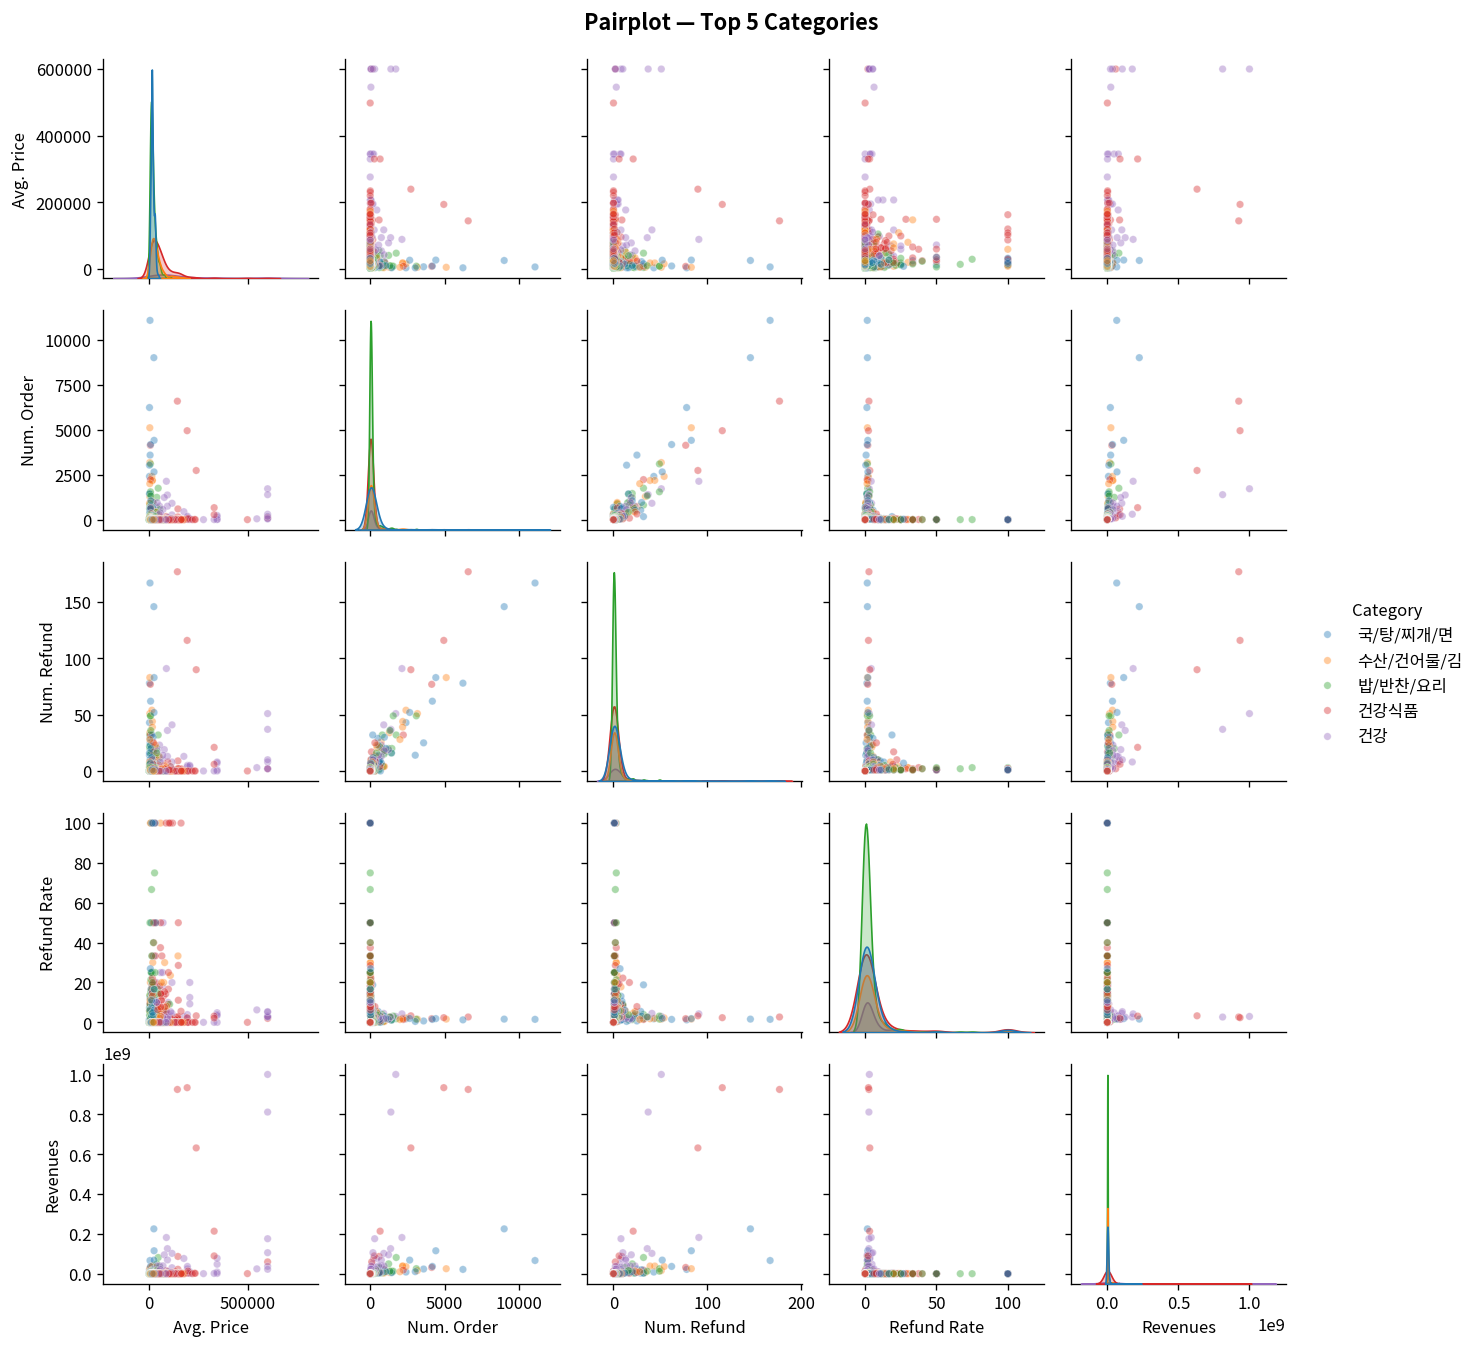

In [20]:
# Pairplot across key numeric variables, colored by category
# I filtered to the top 5 categories only to keep it readable
PAIRPLOT_COLS = ['Avg. Price', 'Num. Order', 'Num. Refund', 'Refund Rate', 'Revenues', 'Category']
df_pair = df[df['Category'].isin(top5_cats)][PAIRPLOT_COLS].copy()

g = sns.pairplot(df_pair, hue='Category', diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 20},
                 height=2.2)
g.fig.suptitle('Pairplot — Top 5 Categories', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('chart_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

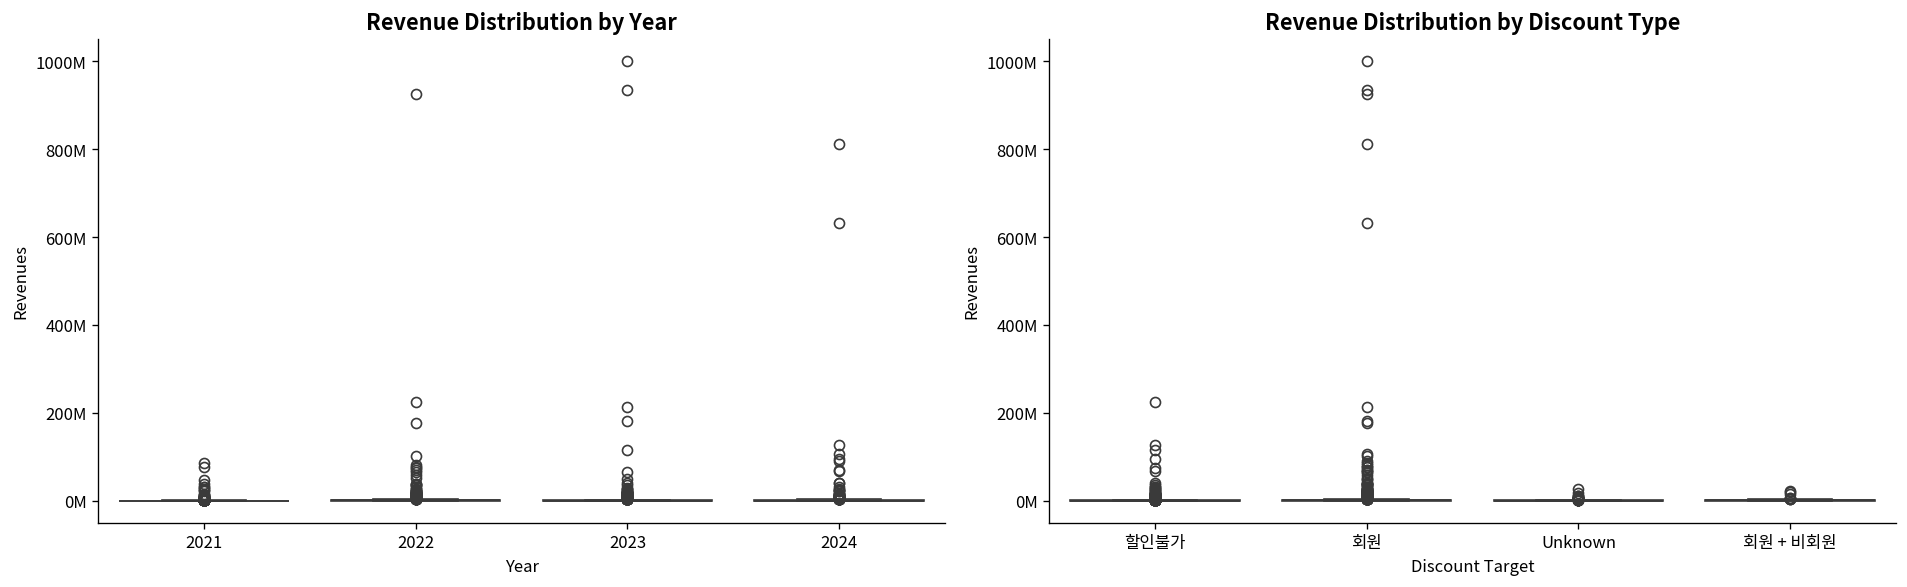

In [21]:
# Boxplots to see revenue distribution — useful for spotting outliers
# and comparing spread across years and discount types
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x='Year', y='Revenues', data=df, palette='Blues', ax=axes[0])
axes[0].set_title('Revenue Distribution by Year', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

sns.boxplot(x='Discount Target', y='Revenues', data=df, palette='Blues', ax=axes[1])
axes[1].set_title('Revenue Distribution by Discount Type', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('chart_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 SKU-Level RFM Segmentation

Classic RFM (Recency / Frequency / Monetary) segments *customers*, but this
dataset has no customer ID anywhere — sales are only captured at the
daily-aggregate and yearly product-snapshot level. Rather than force a
customer segmentation the data can't support, I adapt the same RFM logic to
the SKU/product level, which the business can act on directly (inventory,
delisting, reorder priority):

- **Recency** — years since the product last appeared with sales (0 = active
  in the most recent year in the dataset)
- **Frequency** — total order count across all years
- **Monetary** — total revenue across all years

Each dimension is scored 1–5 and combined into six portfolio segments.

In [22]:
sku = (
    df.groupby('Product')
    .agg(
        Frequency=('Num. Order', 'sum'),
        Monetary=('Revenues', 'sum'),
        Last_Year=('Year', 'max'),
        Category=('Category', 'first'),
    )
    .reset_index()
)

LATEST_YEAR = df['Year'].max()
sku['Recency_Years'] = LATEST_YEAR - sku['Last_Year']
sku['R_Score'] = sku['Recency_Years'].map({0: 5, 1: 3, 2: 2, 3: 1}).fillna(1).astype(int)

def qscore(s):
    ranks = s.rank(method='first')
    return pd.qcut(ranks, 5, labels=[1, 2, 3, 4, 5]).astype(int)

sku['F_Score'] = qscore(sku['Frequency'])
sku['M_Score'] = qscore(sku['Monetary'])

def segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4: return 'Star Performers'
    if r <= 2 and f >= 4 and m >= 4: return 'Declining Stars (At Risk)'
    if r >= 4 and f <= 2 and m <= 2: return 'New / Niche SKUs'
    if r <= 2 and f <= 2 and m <= 2: return 'Dormant / Long-tail'
    if f >= 3 and m >= 3:            return 'Steady Sellers'
    return 'Needs Review'

sku['Segment'] = sku.apply(segment, axis=1)

seg_summary = (
    sku.groupby('Segment')
    .agg(SKUs=('Product', 'count'), Total_Revenue=('Monetary', 'sum'), Avg_Orders=('Frequency', 'mean'))
    .assign(**{'Revenue_Share_%': lambda d: (d['Total_Revenue'] / d['Total_Revenue'].sum() * 100).round(1)})
    .sort_values('Total_Revenue', ascending=False)
)
seg_summary

,SKUs,Total_Revenue,Avg_Orders,Revenue_Share_%
Segment,,,,
Star Performers,250,6185441760,625.824000,51.4
Declining Stars (At Risk),196,2805624230,371.964286,23.3
Steady Sellers,650,2670016880,111.767692,22.2
Needs Review,589,309010950,15.480475,2.6
Dormant / Long-tail,346,58197540,5.144509,0.5
New / Niche SKUs,86,15692440,7.313953,0.1


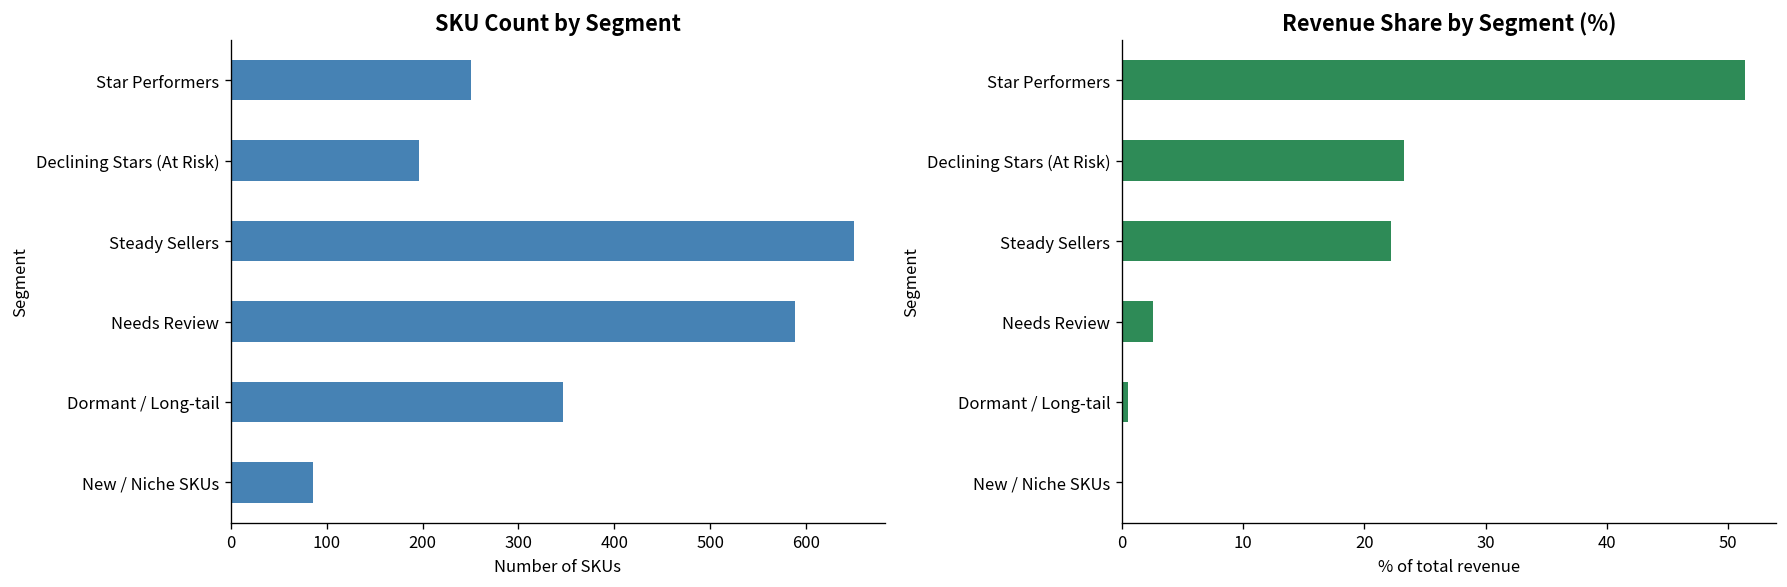

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

seg_summary['SKUs'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('SKU Count by Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of SKUs')

seg_summary['Revenue_Share_%'].plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].invert_yaxis()
axes[1].set_title('Revenue Share by Segment (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% of total revenue')

plt.tight_layout()
plt.savefig('chart_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

**Classic Pareto pattern, with a warning sign.** ~12% of SKUs ("Star
Performers") generate roughly half of all revenue — expected for a
long-tail marketplace catalog. What's actionable is the **"Declining Stars
(At Risk)"** segment: these are SKUs with historically high order volume and
revenue that haven't sold recently. They represent close to a quarter of
total historical revenue sitting in products that may already be
discontinued, out of stock, or losing shelf placement — a concrete list for
the merchandising team to triage before that revenue is silently lost.

---
## 6. Revenue Forecasting (SARIMA vs. Prophet) <a id='6'></a>

I forecast the next 12 months of revenue. Rather than assume SARIMA is the right tool, I benchmark it against Prophet on a held-out test window first (Section 6.2) and use whichever model actually performs better for the production forecast (Section 6.3).

### 6.1 Seasonal Decomposition

Before fitting the model, I decomposed the time series to visually confirm
there's a clear trend and seasonal component worth modeling.

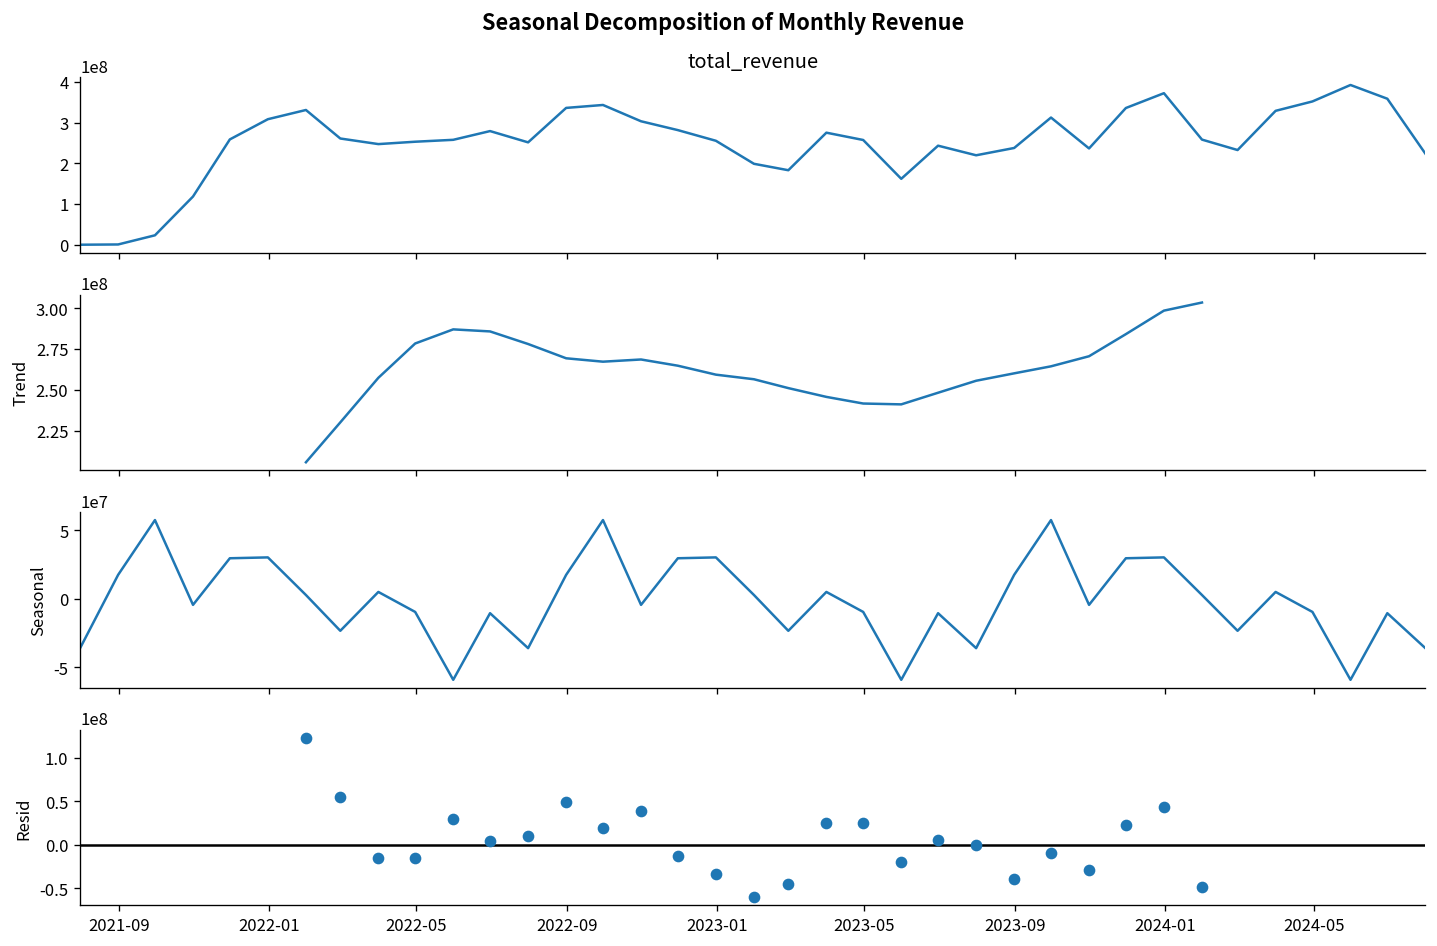

In [24]:
ts = monthly_ts.set_index('date')['total_revenue'].asfreq('ME')

decomp = seasonal_decompose(ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Seasonal Decomposition of Monthly Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Model Comparison: SARIMA vs. Prophet (Accuracy Evaluation)

Before committing to a single forecasting approach for the 12-month
projection, I benchmark SARIMA against Facebook Prophet using a proper
train/test split: the last 6 full months are held out, both models are fit
on everything before that, and I score both on Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).
The most recent month (2024-07) is excluded from both train and test — the
underlying daily sales export was pulled mid-month, so that point is a
partial month, not a genuine low point, and including it would penalize both
models for a data-collection artifact rather than a forecasting error.

In [25]:
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def mape(y, yhat): return np.mean(np.abs((y - yhat) / y)) * 100

ts_full = ts.iloc[:-1]          # drop the partial 2024-07 month
TEST_H  = 6
train, test = ts_full.iloc[:-TEST_H], ts_full.iloc[-TEST_H:]

# SARIMA on the training window
sarima_cv = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_cv_pred = sarima_cv.get_forecast(steps=TEST_H).predicted_mean

# Prophet on the same training window
prophet_train = train.reset_index().rename(columns={'date': 'ds', 'total_revenue': 'y'})
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)
prophet_future   = prophet_model.make_future_dataframe(periods=TEST_H, freq='ME')
prophet_cv_pred  = prophet_model.predict(prophet_future).set_index('ds')['yhat'].reindex(test.index)

model_comparison = pd.DataFrame({
    'Model' : ['SARIMA(1,1,1)(1,1,1,12)', 'Prophet'],
    'MAE'   : [mae(test.values, sarima_cv_pred.values),  mae(test.values, prophet_cv_pred.values)],
    'RMSE'  : [rmse(test.values, sarima_cv_pred.values), rmse(test.values, prophet_cv_pred.values)],
    'MAPE_%': [mape(test.values, sarima_cv_pred.values), mape(test.values, prophet_cv_pred.values)],
}).round(1)
model_comparison

17:56:19 - cmdstanpy - INFO - Chain [1] start processing


17:56:19 - cmdstanpy - INFO - Chain [1] done processing


,Model,MAE,RMSE,MAPE_%
0,"SARIMA(1,1,1)(1,1,1,12)",60451332.3,94892377.2,23.9
1,Prophet,140306610.0,167981964.8,41.0


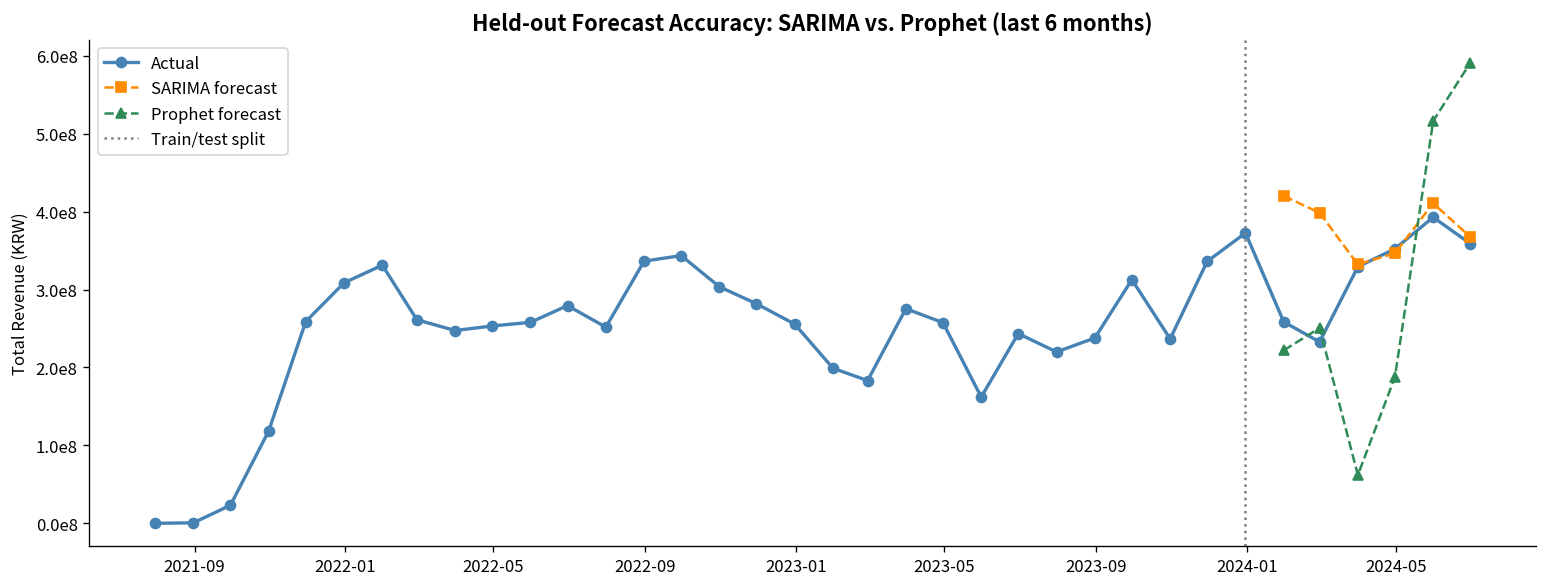

SARIMA MAPE: 23.9%   Prophet MAPE: 41.0%
SARIMA wins on all three metrics. With only ~2.5 years of training history and a strong, regular 12-month cycle, SARIMA's explicit seasonal order captures the pattern more reliably than Prophet's changepoint-based trend model, which typically needs more history to earn its flexibility. I proceed with SARIMA for the production forecast below.


In [26]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts_full.index, ts_full.values, 'o-', color='steelblue', label='Actual', linewidth=2)
ax.plot(test.index, sarima_cv_pred.values, 's--', color='darkorange', label='SARIMA forecast')
ax.plot(test.index, prophet_cv_pred.values, '^--', color='seagreen', label='Prophet forecast')
ax.axvline(train.index[-1], color='gray', linestyle=':', label='Train/test split')
ax.set_title('Held-out Forecast Accuracy: SARIMA vs. Prophet (last 6 months)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Revenue (KRW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e8:.1f}e8'))
ax.legend()
plt.tight_layout()
plt.savefig('chart_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"SARIMA MAPE: {model_comparison.loc[0, 'MAPE_%']}%   Prophet MAPE: {model_comparison.loc[1, 'MAPE_%']}%")
print("SARIMA wins on all three metrics. With only ~2.5 years of training history and a strong, "
      "regular 12-month cycle, SARIMA's explicit seasonal order captures the pattern more reliably "
      "than Prophet's changepoint-based trend model, which typically needs more history to earn its "
      "flexibility. I proceed with SARIMA for the production forecast below.")

### 6.3 Final Forecast (SARIMA)

Based on the comparison in 6.2, I refit SARIMA on the full history (all 36 complete months) for the actual forward-looking forecast.

In [27]:
# Fit SARIMA(1,1,1)(1,1,1,12)
# The seasonal order of 12 matches the monthly data with yearly seasonality
sarima = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
print(sarima.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                      total_revenue   No. Observations:                   37
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -465.686
Date:                            Mon, 27 Jul 2026   AIC                            941.372
Time:                                    17:56:19   BIC                            947.262
Sample:                                07-31-2021   HQIC                           942.934
                                     - 07-31-2024                                         
Covariance Type:                              opg                                         


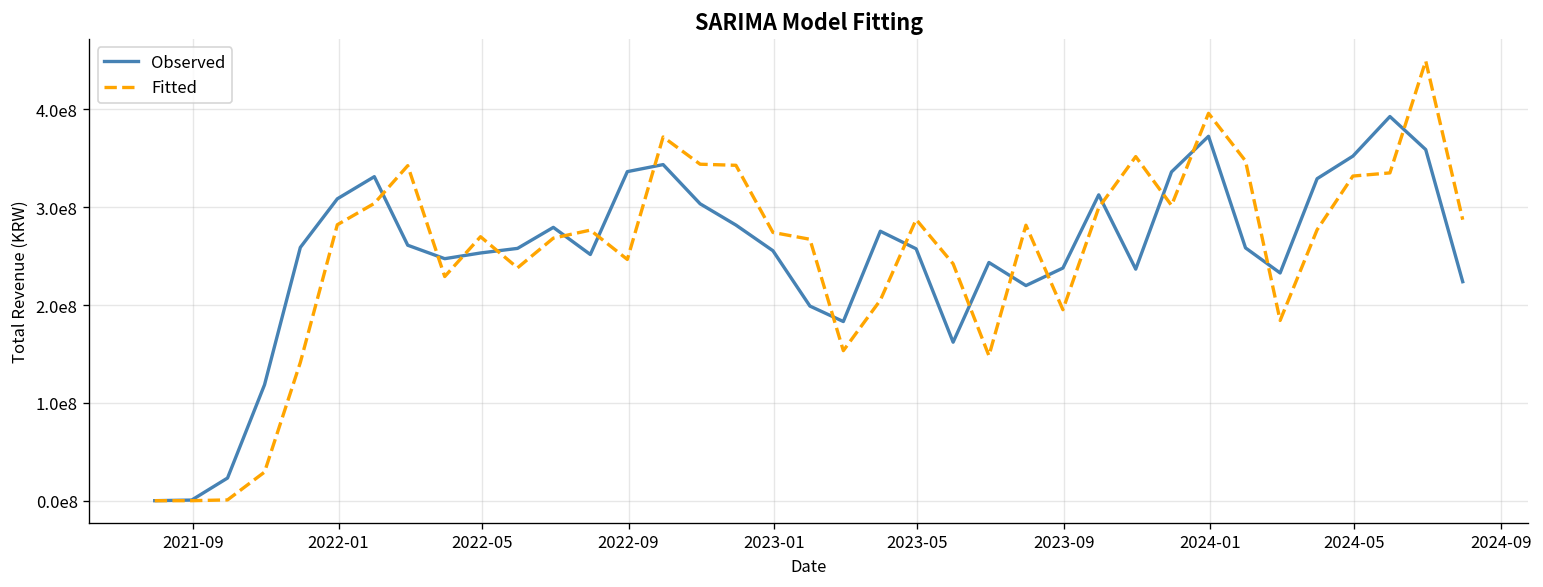

In [28]:
# Check how well the model fits the historical data before trusting the forecast
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values,           label='Observed', linewidth=2, color='steelblue')
ax.plot(ts.index, sarima.fittedvalues, label='Fitted',   linewidth=2, color='orange', linestyle='--')
ax.set_title('SARIMA Model Fitting', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Revenue (KRW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e8:.1f}e8'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_sarima_fit.png', dpi=150, bbox_inches='tight')
plt.show()

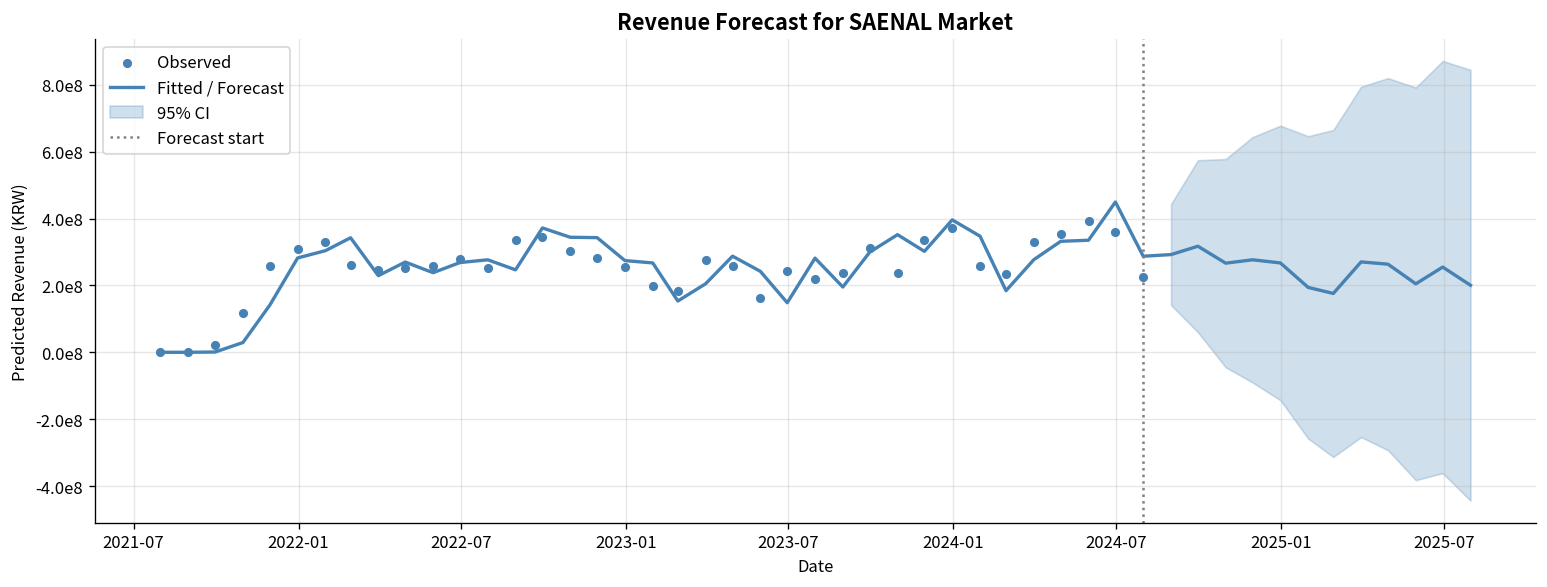


Forecast summary (next 12 months):
                Forecast      Lower CI      Upper CI
2024-08-31  2.922326e+08  1.413382e+08  4.431271e+08
2024-09-30  3.172244e+08  6.004994e+07  5.743988e+08
2024-10-31  2.665263e+08 -4.496016e+07  5.780128e+08
2024-11-30  2.766587e+08 -9.039363e+07  6.437111e+08
2024-12-31  2.672431e+08 -1.432230e+08  6.777092e+08
2025-01-31  1.940178e+08 -2.581427e+08  6.461783e+08
2025-02-28  1.759829e+08 -3.130502e+08  6.650160e+08
2025-03-31  2.703015e+08 -2.536933e+08  7.942963e+08
2025-04-30  2.634903e+08 -2.929112e+08  8.198919e+08
2025-05-31  2.047474e+08 -3.824699e+08  7.919647e+08
2025-06-30  2.548589e+08 -3.615303e+08  8.712480e+08
2025-07-31  2.004920e+08 -4.438065e+08  8.447906e+08


In [29]:
# Generate 12-month forecast with 95% confidence interval
FORECAST_STEPS = 12
forecast = sarima.get_forecast(steps=FORECAST_STEPS)
fc_mean  = forecast.predicted_mean
fc_ci    = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(ts.index, ts.values, color='steelblue', s=20, zorder=3, label='Observed')

# Connect the fitted line seamlessly into the forecast
full_index  = ts.index.tolist() + fc_mean.index.tolist()
full_values = sarima.fittedvalues.tolist() + fc_mean.tolist()
ax.plot(full_index, full_values, color='steelblue', linewidth=2, label='Fitted / Forecast')

# Shade the uncertainty band
ax.fill_between(fc_ci.index,
                fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                alpha=0.25, color='steelblue', label='95% CI')

ax.axvline(ts.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Forecast start')
ax.set_title('Revenue Forecast for SAENAL Market', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Predicted Revenue (KRW)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e8:.1f}e8'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nForecast summary (next 12 months):')
print(pd.DataFrame({
    'Forecast' : fc_mean,
    'Lower CI' : fc_ci.iloc[:,0],
    'Upper CI' : fc_ci.iloc[:,1]
}).to_string())

---
## 7. Export for Tableau <a id='7'></a>

I exported analysis-ready CSVs so the same data can be visualized
interactively in Tableau Public — the original five, plus four new ones
covering SKU-level RFM segments, the category growth-share matrix, vendor
concentration metrics, and the SARIMA vs. Prophet accuracy comparison.

In [30]:
import os

# Full product-level table for detailed filtering in Tableau
df.to_csv('tableau_products.csv', index=False, encoding='utf-8-sig')

# Monthly revenue series for the trend / forecast dashboard
monthly_ts.to_csv('tableau_monthly_revenue.csv', index=False, encoding='utf-8-sig')

# Revenue by year × category for the category breakdown view
yearly_cat.to_csv('tableau_category_revenue.csv', index=False, encoding='utf-8-sig')

# Revenue by discount type for the loyalty program view
discount_rev.to_csv('tableau_discount_revenue.csv', index=False, encoding='utf-8-sig')

# SARIMA forecast with confidence interval bounds
pd.DataFrame({
    'date'     : fc_mean.index,
    'forecast' : fc_mean.values,
    'lower_ci' : fc_ci.iloc[:,0].values,
    'upper_ci' : fc_ci.iloc[:,1].values,
}).to_csv('tableau_forecast.csv', index=False, encoding='utf-8-sig')

# Combined actual + forecast for the trend & forecast chart in Tableau
# Actual rows have null CI values; Forecast rows include upper/lower bounds
actual_ts = monthly_ts.rename(columns={'date': 'date', 'total_revenue': 'value'}).copy()
actual_ts['type']     = 'Actual'
actual_ts['upper_ci'] = None
actual_ts['lower_ci'] = None

forecast_ts = pd.DataFrame({
    'date'     : fc_mean.index,
    'value'    : fc_mean.values,
    'type'     : 'Forecast',
    'upper_ci' : fc_ci.iloc[:,0].values,
    'lower_ci' : fc_ci.iloc[:,1].values,
})

combined_ts = (
    pd.concat([actual_ts[['date','value','type','upper_ci','lower_ci']],
               forecast_ts],
              ignore_index=True)
    .sort_values('date')
    .reset_index(drop=True)
)
combined_ts.to_csv('tableau_combined_revenue.csv', index=False, encoding='utf-8-sig')

# SKU-level RFM segmentation
sku[['Product', 'Category', 'Frequency', 'Monetary', 'Recency_Years',
     'R_Score', 'F_Score', 'M_Score', 'Segment']].to_csv(
    'tableau_sku_rfm.csv', index=False, encoding='utf-8-sig')

# Category growth-share matrix
cat_matrix.reset_index().to_csv('tableau_category_matrix.csv', index=False, encoding='utf-8-sig')

# Vendor concentration summary (HHI / CR4 across four bases)
concentration_summary.to_csv('tableau_vendor_concentration.csv', index=False, encoding='utf-8-sig')

# SARIMA vs. Prophet accuracy comparison
model_comparison.to_csv('tableau_model_comparison.csv', index=False, encoding='utf-8-sig')

print('Exported:')
for f in sorted(x for x in os.listdir('.') if x.startswith('tableau_')):
    print(f'  {f}  ({os.path.getsize(f):,} bytes)')

Exported:
  tableau_category_matrix.csv  (3,431 bytes)
  tableau_category_revenue.csv  (3,939 bytes)
  tableau_combined_revenue.csv  (2,110 bytes)
  tableau_discount_revenue.csv  (117 bytes)
  tableau_forecast.csv  (828 bytes)
  tableau_model_comparison.csv  (115 bytes)
  tableau_monthly_revenue.csv  (787 bytes)
  tableau_products.csv  (600,260 bytes)
  tableau_sku_rfm.csv  (237,767 bytes)
  tableau_vendor_concentration.csv  (228 bytes)
